# Проект: Предсказание сердечных приступов

## 🎯 Цель работы
Разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

## 📋 Описание проекта
В этом проекте предполагается работа с датасетом из открытого источника. Необходимо разработать модель машинного обучения, а также подготовить библиотеку и интерфейс к ней для предсказания на тестовой выборке. В начале проекта вам будет доступен обучающий датасет и тестовый датасет, не содержащий правильных ответов. Метрика на тестовом датасете будет измерена в ходе проверки работы.

## 📊 Ожидаемые результаты проекта
- ***Исследование датасета*** (предполагается поиск дополнительной информации для лучшего понимания природы данных)
- ***Предобработка данных***. Будьте внимательны: в данных могут быть бесполезные признаки, сильно скорелированные признаки а также косвенные утечки целевого признака. Некоторые колонки потребуется преобразовать к нужному типу данных.
- ***Обучение модели***
- ***Подготовка предсказания на тестовой выборке**. Файл предсказаний должен быть в csv формате и содержать 2 столбца: “id” и “prediction”. 
- ***Подготовка скриптов и библиотеки для обработки данных и предсказания на тестовой выборке***
- ***Написание инструмента для тестирования***
- ***Оформление документации***

## GitHub:
https://github.com/sandyclawz/hearth_attacks

***Данные пациентов для предсказания риска сердечных приступов***:
- id  - id
- Антропометрические параметры (вес, возраст, рост)
- Привычки (курение, качество сна и т.д)
- Давление
- Наличие хронических заболеваний
- Биохимия крови
- Таргет - высокий или низкий риск поражения сердца

***Стек***:
- Python (ООП)
- Pandas
- numpy
- Scikitlearn
- CatBoost
- FastAPI
- HTML

# Загружаем все модули Python

In [35]:
#Загружаем все модули
#!pip install phik
!pip -q install shap
#!pip install scikit-learn==1.1.3 -q
#!pip install --upgrade jupyterlab_widgets ipywidgets

#загружаем библиотеки
import pandas as pd
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import sklearn
#import phik

from pathlib import Path
from IPython.display import display, HTML
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler
#from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix, recall_score, precision_score, precision_recall_curve
from sklearn.metrics import roc_auc_score, make_scorer
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.datasets import fetch_california_housing
#from phik.report import plot_correlation_matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [36]:
print(sklearn.__version__)

1.6.1


# Задаем константы

In [2]:
RANDOM_STATE = 42
TARGET = "heart_attack_risk_binary"
ID_COL = "id"

# Создаём функции/классы

In [3]:
# Загрузка файлов обработки
def load_csv(path: str | Path) -> pd.DataFrame:

    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Файл не найден: {path}")
    df = pd.read_csv(path, sep=",")
    df = df.drop(columns=["Unnamed: 0"], errors="ignore")
    return df

# Проверить общую информацию
def data_review(df, name):
    print(f'=== {name} ===')
    display(df.head(5))
    print()
    print(df.info())
    print()
    print('Пропуски:')
    print(df.isna().sum())
    print()
    print('Полные дубликаты:', df.duplicated().sum())
    print('Дубликаты id:', df['id'].duplicated().sum())
    print('-' * 50)

# Приведение название колонок к snake
def clean_column_names(df):
    df = df.copy()
    
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[()]", "", regex=True)
        .str.replace("-", "_", regex=False)
    )
    
    return df

In [4]:
class DataProcessor:
    def __init__(self, target_col=TARGET, id_col=ID_COL):
        self.target_col = target_col
        self.id_col = id_col
        self.binary_cols = [
            "diabetes",
            "family_history",
            "smoking",
            "obesity",
            "alcohol_consumption",
            "previous_heart_problems",
            "medication_use"
        ]
        self.ordinal_cols = [
            "diet",
            "stress_level",
            "physical_activity_days_per_week"
        ]
        self.categorical_cols = [
            "gender"
        ]

    def clean_column_names(self, df):
        df = df.copy()
        df.columns = (
            df.columns
            .str.strip()
            .str.lower()
            .str.replace(r"\s+", "_", regex=True)
            .str.replace(r"[()]", "", regex=True)
            .str.replace("-", "_", regex=False)
        )
        return df

    def clean_gender(self, df):
        df = df.copy()
        gender_map = {
            "Male": "male",
            "Female": "female",
            "1.0": "male",
            "0.0": "female",
            1.0: "male",
            0.0: "female",
            1: "male",
            0: "female"
        }
        if "gender" in df.columns:
            df["gender"] = df["gender"].replace(gender_map)
        return df

    def prepare_dataframe(self, df):
        df = df.copy()
        df = self.clean_column_names(df)
        df = self.clean_gender(df)
        df = df.drop(columns=["unnamed:_0", "unnamed_0"], errors="ignore")
        return df

    def split_features_target(self, df):
        df = self.prepare_dataframe(df)
        X = df.drop(columns=[self.target_col, self.id_col], errors="ignore")
        y = df[self.target_col].astype(int)
        return X, y

    def prepare_test(self, df):
        df = self.prepare_dataframe(df)
        ids = df[self.id_col].copy()
        X = df.drop(columns=[self.target_col, self.id_col], errors="ignore")
        return X, ids

    def get_column_groups(self, X):
        cat_cols = [col for col in self.categorical_cols if col in X.columns]
        num_cols = [col for col in X.columns if col not in cat_cols]
        return num_cols, cat_cols

In [5]:
class EDAReporter:
    def __init__(self, target_col=TARGET, id_col=ID_COL):
        self.target_col = target_col
        self.id_col = id_col

    def review(self, df, name):
        print(f"=== {name} ===")
        display(df.head())
        print()
        print(df.info())
        print()
        print("Пропуски:")
        print(df.isna().sum())
        print()
        print("Полные дубликаты:", df.duplicated().sum())
        if self.id_col in df.columns:
            print("Дубликаты id:", df[self.id_col].duplicated().sum())
        print("-" * 50)

    def target_distribution(self, df):
        if self.target_col not in df.columns:
            print("Целевой признак отсутствует")
            return
        counts = df[self.target_col].value_counts()
        shares = df[self.target_col].value_counts(normalize=True).round(4)
        report = pd.DataFrame({
            "count": counts,
            "share": shares
        })
        display(report)
        counts.plot(kind="bar")
        plt.title("Распределение целевого признака")
        plt.xlabel("Класс")
        plt.ylabel("Количество")
        plt.show()

    def missing_report(self, df):
        report = pd.DataFrame({
            "missing": df.isna().sum(),
            "missing_share": df.isna().mean().round(4),
            "dtype": df.dtypes.astype(str),
            "n_unique": df.nunique()
        })
        report = report.sort_values("missing", ascending=False)
        display(report)

    def numeric_distributions(self, df, columns=None):
        if columns is None:
            columns = df.select_dtypes(include=["int64", "float64", "Int64"]).columns
            columns = [col for col in columns if col not in [self.id_col, self.target_col]]
        for col in columns:
            plt.figure(figsize=(6, 4))
            df[col].hist(bins=30)
            plt.title(f"Распределение признака: {col}")
            plt.xlabel(col)
            plt.ylabel("Количество")
            plt.show()

In [6]:
#Проверка утечек и мультиколлинеарности
class FeatureAnalyzer:
    def __init__(self, target_col=TARGET, id_col=ID_COL):
        self.target_col = target_col
        self.id_col = id_col

    def check_high_correlation(self, X, threshold=0.9):
        numeric_X = X.select_dtypes(include=["int64", "float64", "Int64"])
        corr_matrix = numeric_X.corr().abs()

        upper = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )

        high_corr = []

        for col in upper.columns:
            for row in upper.index:
                value = upper.loc[row, col]

                if pd.notna(value) and value >= threshold:
                    high_corr.append({
                        "feature_1": row,
                        "feature_2": col,
                        "correlation": value
                    })

        high_corr_df = pd.DataFrame(
            high_corr,
            columns=["feature_1", "feature_2", "correlation"]
        )

        if high_corr_df.empty:
            print(f"Пар признаков с корреляцией выше {threshold} не найдено")
            return high_corr_df

        return high_corr_df.sort_values("correlation", ascending=False)

    def check_target_correlation(self, df, threshold=0.7):
        numeric_df = df.select_dtypes(include=["int64", "float64", "Int64"])

        if self.target_col not in numeric_df.columns:
            print(f"Целевой признак {self.target_col} не найден")
            return pd.DataFrame(
                columns=["feature", "abs_correlation_with_target"]
            )

        corr_with_target = (
            numeric_df
            .corr()[self.target_col]
            .drop(self.target_col)
            .abs()
            .sort_values(ascending=False)
        )

        result = (
            corr_with_target[corr_with_target >= threshold]
            .reset_index()
        )

        result.columns = ["feature", "abs_correlation_with_target"]

        if result.empty:
            print(f"Признаков с корреляцией с таргетом выше {threshold} не найдено")

        return result

    def check_suspicious_features(self, columns):
        suspicious_words = [
            "risk",
            "attack",
            "target",
            "diagnosis",
            "result",
            "outcome",
            "prediction",
            "score"
        ]

        suspicious_cols = []

        for col in columns:
            for word in suspicious_words:
                if word in col.lower() and col != self.target_col:
                    suspicious_cols.append(col)

        return sorted(set(suspicious_cols))

In [7]:
#Выбор метрики
class MetricEvaluator:
    def __init__(self, main_metric="f1_macro"):
        self.main_metric = main_metric

    def evaluate(self, y_true, y_pred, model_name):
        report = classification_report(y_true, y_pred, output_dict=True)
        macro_f1 = f1_score(y_true, y_pred, average="macro")
        weighted_f1 = f1_score(y_true, y_pred, average="weighted")

        result = {
            "model": model_name,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "accuracy": report["accuracy"],
            "recall_class_1": report["1"]["recall"],
            "precision_class_1": report["1"]["precision"],
            "f1_class_1": report["1"]["f1-score"]
        }

        print(f"=== {model_name} ===")
        print(classification_report(y_true, y_pred))

        return result

In [8]:
#Модели для обучения
class ModelFactory:
    def __init__(self, random_state=RANDOM_STATE):
        self.random_state = random_state

    def get_models(self):
        models = {
            "LogisticRegression": LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=self.random_state
            ),
            "DecisionTree": DecisionTreeClassifier(
                max_depth=5,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=self.random_state
            ),
            "RandomForest": RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=self.random_state,
                n_jobs=-1
            ),
            "KNeighbors": KNeighborsClassifier(
                n_neighbors=15
            )
        }

        return models

In [9]:
class PipelineBuilder:
    def __init__(self, numeric_cols, categorical_cols):
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols

    def build_preprocessor(self):
        numeric_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_transformer = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ])

        preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, self.numeric_cols),
                ("cat", categorical_transformer, self.categorical_cols)
            ]
        )

        return preprocessor

    def build_pipeline(self, model):
        pipeline = Pipeline(steps=[
            ("preprocessor", self.build_preprocessor()),
            ("model", model)
        ])
        return pipeline

In [10]:
class ModelTrainer:
    def __init__(self, pipeline_builder, metric_evaluator, random_state=RANDOM_STATE):
        self.pipeline_builder = pipeline_builder
        self.metric_evaluator = metric_evaluator
        self.random_state = random_state
        self.results = []
        self.trained_models = {}

    def train_valid_split(self, X, y):
        return train_test_split(
            X,
            y,
            test_size=0.25,
            random_state=self.random_state,
            stratify=y
        )

    def train_models(self, X, y, models):
        X_train, X_valid, y_train, y_valid = self.train_valid_split(X, y)

        for model_name, model in models.items():
            pipeline = self.pipeline_builder.build_pipeline(model)
            pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict(X_valid)

            result = self.metric_evaluator.evaluate(
                y_true=y_valid,
                y_pred=y_pred,
                model_name=model_name
            )

            self.results.append(result)
            self.trained_models[model_name] = pipeline

        results_df = pd.DataFrame(self.results).sort_values("macro_f1", ascending=False)

        return results_df, self.trained_models

In [11]:
class FinalModel:
    def __init__(self, model, model_path="models/final_model.joblib"):
        self.model = model
        self.model_path = Path(model_path)

    def fit(self, X, y):
        self.model.fit(X, y)
        return self

    def save(self):
        self.model_path.parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(self.model, self.model_path)
        print(f"Модель сохранена: {self.model_path}")

    def load(self):
        self.model = joblib.load(self.model_path)
        return self.model

    def predict(self, X):
        return self.model.predict(X)

In [12]:
class SubmissionMaker:
    def __init__(self, id_col=ID_COL):
        self.id_col = id_col

    def make_submission(self, ids, predictions):
        submission = pd.DataFrame({
            "id": ids,
            "prediction": predictions.astype(int)
        })
        return submission

    def save_submission(self, submission, path="data/predictions/submission.csv"):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)

        submission.to_csv(path, index=True)

        print(f"Файл предсказаний сохранён: {path}")
        print("Размер файла:", submission.shape)

        return path

# Загрузка и предобработка данных

## Загружаем и анализируем данные

In [13]:
DATA_DIR = Path("../data/raw")
train = load_csv(DATA_DIR / "heart_train.csv")
test = load_csv(DATA_DIR / "heart_test.csv")

In [14]:
data_review(train, 'Данные для тренировки')
data_review(test, 'Данные для теста')

=== Данные для тренировки ===


,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,...,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,...,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,...,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,...,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,...,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,...,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              8685 non-null   float64
 1   Cholesterol                      8685 non-null   float64
 2   Heart rate                       8685 non-null   float64
 3   Diabetes                         8442 non-null   float64
 4   Family History                   8442 non-null   float64
 5   Smoking                          8442 non-null   float64
 6   Obesity                          8442 non-null   float64
 7   Alcohol Consumption              8442 non-null   float64
 8   Exercise Hours Per Week          8685 non-null   float64
 9   Diet                             8685 non-null   int64  
 10  Previous Heart Problems          8442 non-null   float64
 11  Medication Use                   8442 non-null   float64
 12  Stress Level       

,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,...,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,2,...,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093,7746
1,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,2,...,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860,4202
2,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,0,...,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070,6632
3,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,0,...,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814,4639
4,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,0,...,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349,4825



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              966 non-null    float64
 1   Cholesterol                      966 non-null    float64
 2   Heart rate                       966 non-null    float64
 3   Diabetes                         935 non-null    float64
 4   Family History                   935 non-null    float64
 5   Smoking                          935 non-null    float64
 6   Obesity                          935 non-null    float64
 7   Alcohol Consumption              935 non-null    float64
 8   Exercise Hours Per Week          966 non-null    float64
 9   Diet                             966 non-null    int64  
 10  Previous Heart Problems          935 non-null    float64
 11  Medication Use                   935 non-null    float64
 12  Stress Level         

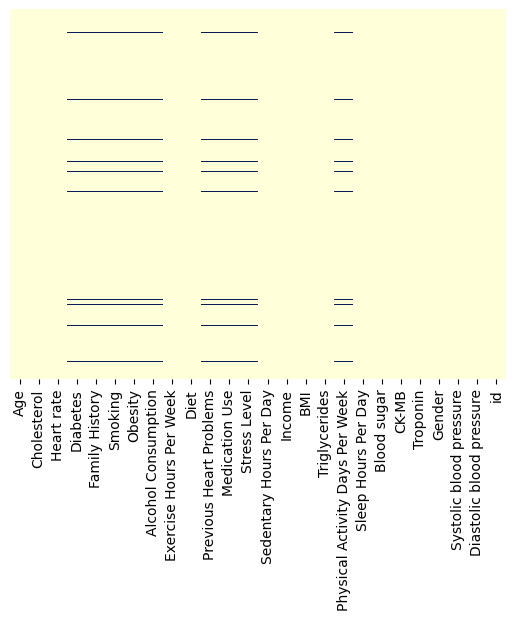

In [15]:
#Визуализация пропусков
sns.heatmap(train.isna(), yticklabels=False, cbar=False, cmap="YlGnBu");
sns.heatmap(test.isna(), yticklabels=False, cbar=False, cmap="YlGnBu");

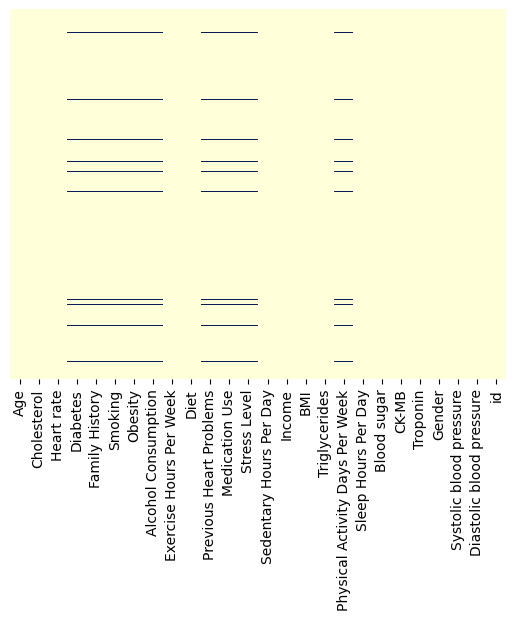

In [16]:
#Визуализация пропусков
sns.heatmap(test.isna(), yticklabels=False, cbar=False, cmap="YlGnBu");

Полных дупликатов нет.

Пропуски в данных оставляем для дальнейшей работы и обработке на стадии паплайна.


## Предобработка данных

In [17]:
processor = DataProcessor()
eda = EDAReporter()

train_clean = processor.prepare_dataframe(train)
test_clean = processor.prepare_dataframe(test)

eda.review(train_clean, "Данные для тренировки")
eda.review(test_clean, "Данные для теста")

=== Данные для тренировки ===


,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,...,physical_activity_days_per_week,sleep_hours_per_day,heart_attack_risk_binary,blood_sugar,ck_mb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure,id
0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,1,...,3.0,0.333333,0.0,0.227018,0.048229,0.036512,male,0.212903,0.709302,2664
1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,2,...,3.0,0.833333,0.0,0.150198,0.017616,0.000194,female,0.412903,0.569767,9287
2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,2,...,2.0,1.000000,0.0,0.227018,0.048229,0.036512,female,0.238710,0.220930,5379
3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,0,...,0.0,0.333333,1.0,0.227018,0.048229,0.036512,female,0.348387,0.267442,8222
4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,1,...,5.0,1.000000,1.0,0.227018,0.048229,0.036512,male,0.619355,0.441860,4047



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              8685 non-null   float64
 1   cholesterol                      8685 non-null   float64
 2   heart_rate                       8685 non-null   float64
 3   diabetes                         8442 non-null   float64
 4   family_history                   8442 non-null   float64
 5   smoking                          8442 non-null   float64
 6   obesity                          8442 non-null   float64
 7   alcohol_consumption              8442 non-null   float64
 8   exercise_hours_per_week          8685 non-null   float64
 9   diet                             8685 non-null   int64  
 10  previous_heart_problems          8442 non-null   float64
 11  medication_use                   8442 non-null   float64
 12  stress_level       

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,...,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,blood_sugar,ck_mb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure,id
0,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,2,...,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,male,0.283871,0.372093,7746
1,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,2,...,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,female,0.703226,0.441860,4202
2,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,0,...,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,male,0.458065,0.779070,6632
3,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,0,...,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,female,0.741935,0.255814,4639
4,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,0,...,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,male,0.412903,0.395349,4825



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              966 non-null    float64
 1   cholesterol                      966 non-null    float64
 2   heart_rate                       966 non-null    float64
 3   diabetes                         935 non-null    float64
 4   family_history                   935 non-null    float64
 5   smoking                          935 non-null    float64
 6   obesity                          935 non-null    float64
 7   alcohol_consumption              935 non-null    float64
 8   exercise_hours_per_week          966 non-null    float64
 9   diet                             966 non-null    int64  
 10  previous_heart_problems          935 non-null    float64
 11  medication_use                   935 non-null    float64
 12  stress_level         

,count,share
heart_attack_risk_binary,,
0.0,5672,0.6531
1.0,3013,0.3469


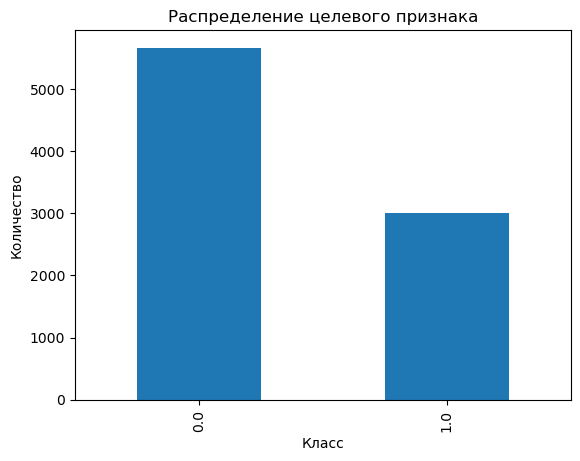

In [18]:
eda.target_distribution(train_clean)

In [19]:
eda.missing_report(train_clean)

,missing,missing_share,dtype,n_unique
physical_activity_days_per_week,243,0.028,float64,8
diabetes,243,0.028,float64,2
family_history,243,0.028,float64,2
smoking,243,0.028,float64,2
obesity,243,0.028,float64,2
alcohol_consumption,243,0.028,float64,2
previous_heart_problems,243,0.028,float64,2
medication_use,243,0.028,float64,2
stress_level,243,0.028,float64,10
troponin,0,0.000,float64,340


In [20]:
eda.missing_report(test_clean)

,missing,missing_share,dtype,n_unique
diabetes,31,0.0321,float64,2
family_history,31,0.0321,float64,2
smoking,31,0.0321,float64,2
obesity,31,0.0321,float64,2
alcohol_consumption,31,0.0321,float64,2
physical_activity_days_per_week,31,0.0321,float64,8
previous_heart_problems,31,0.0321,float64,2
medication_use,31,0.0321,float64,2
stress_level,31,0.0321,float64,10
age,0,0.0000,float64,73


In [21]:
X, y = processor.split_features_target(train)
X_test, test_ids = processor.prepare_test(test)

num_cols, cat_cols = processor.get_column_groups(X)

print("Числовые признаки:", num_cols)
print("Категориальные признаки:", cat_cols)

Числовые признаки: ['age', 'cholesterol', 'heart_rate', 'diabetes', 'family_history', 'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week', 'diet', 'previous_heart_problems', 'medication_use', 'stress_level', 'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides', 'physical_activity_days_per_week', 'sleep_hours_per_day', 'blood_sugar', 'ck_mb', 'troponin', 'systolic_blood_pressure', 'diastolic_blood_pressure']
Категориальные признаки: ['gender']


## 📋 Выводы по распределению целевого признака, пропускам и типам данных

Целевой признак `heart_attack_risk_binary` имеет умеренный дисбаланс классов. Класс `0` встречается в 5672 наблюдениях, что составляет 65.3% обучающей выборки. Класс `1` встречается в 3013 наблюдениях, или 34.7% выборки.

Дисбаланс не является критическим, но учитывать его необходимо. Метрика `accuracy` в такой ситуации может быть недостаточно информативной, так как модель может получать приемлемое качество за счёт более частого предсказания класса `0`. Поэтому для дальнейшего сравнения моделей целесообразно использовать `macro F1-score`, а также отдельно контролировать `recall` по классу `1`, так как он соответствует пациентам с высоким риском сердечного приступа.

В обучающей и тестовой выборках пропуски обнаружены в одном и том же наборе признаков:

`diabetes`, `family_history`, `smoking`, `obesity`, `alcohol_consumption`, `previous_heart_problems`, `medication_use`, `stress_level`, `physical_activity_days_per_week`.

В обучающей выборке в каждой из этих колонок пропущено по 243 значения, что составляет 2.8% данных. В тестовой выборке пропущено по 31 значению, или 3.21% данных. Поскольку пропуски есть и в train, и в test, удалять строки с пропусками нецелесообразно. Это привело бы к потере части обучающих данных и не решило бы проблему обработки тестовой выборки.

Большинство признаков с пропусками являются бинарными или дискретными: например, наличие диабета, курение, ожирение, семейная история заболеваний, приём лекарств, уровень стресса и количество дней физической активности. Для таких признаков пропуски лучше обрабатывать внутри пайплайна с помощью `SimpleImputer`. В качестве базового решения можно использовать заполнение медианой или наиболее частым значением.

Типы данных в целом корректны для дальнейшего моделирования. Большинство признаков представлены типом `float64`, признак `diet` — типом `int64`, `id` — типом `int64`, а `gender` — типом `object`. Для модели категориальный признак `gender` необходимо закодировать, например через `OneHotEncoder`.

Признак `id` является техническим идентификатором пациента. Его не следует использовать при обучении модели, но он должен быть сохранён для формирования итогового файла предсказаний.

Целевой признак пропусков не содержит, поэтому обучающая выборка пригодна для построения модели.

# Проверка утечек и мультиколлинеарности

In [22]:
feature_analyzer = FeatureAnalyzer()

high_corr_features = feature_analyzer.check_high_correlation(X, threshold=0.9)
display(high_corr_features)

Пар признаков с корреляцией выше 0.9 не найдено


,feature_1,feature_2,correlation


In [23]:
target_corr = feature_analyzer.check_target_correlation(train_clean, threshold=0.7)
display(target_corr)

Признаков с корреляцией с таргетом выше 0.7 не найдено


,feature,abs_correlation_with_target


In [24]:
numeric_df = train_clean.select_dtypes(include=["int64", "float64", "Int64"])

target_corr_all = (
    numeric_df
    .corr()["heart_attack_risk_binary"]
    .drop("heart_attack_risk_binary")
    .abs()
    .sort_values(ascending=False)
)

display(target_corr_all.head(15))

diet                               0.044135
systolic_blood_pressure            0.033762
id                                 0.028198
sleep_hours_per_day                0.019487
cholesterol                        0.018920
diabetes                           0.016213
heart_rate                         0.015561
obesity                            0.015084
alcohol_consumption                0.014546
physical_activity_days_per_week    0.012515
triglycerides                      0.012062
diastolic_blood_pressure           0.011967
ck_mb                              0.009821
exercise_hours_per_week            0.009487
income                             0.008218
Name: heart_attack_risk_binary, dtype: float64

## 🔎 Выводы по корреляции признаков с целевым признаком

Дополнительно была рассчитана абсолютная корреляция числовых признаков с целевым признаком `heart_attack_risk_binary`.

📌 Максимальная корреляция наблюдается у признака `diet`, но её значение составляет всего около `0.044`. Остальные признаки имеют ещё меньшую связь с таргетом: `systolic_blood_pressure` — около `0.034`, `id` — около `0.028`, `sleep_hours_per_day` — около `0.019`, `cholesterol` — около `0.019`.

📉 Такие значения корреляции являются очень низкими. Это означает, что ни один отдельный числовой признак не имеет сильной линейной связи с целевой переменной. Следовательно, явных признаков-утечек по корреляции с таргетом не обнаружено.

⚠️ Отдельно стоит отметить, что `id` попал в список корреляций, но этот признак является техническим идентификатором и не должен использоваться при обучении модели. В дальнейшем он будет исключён из признакового пространства и сохранён только для формирования итогового файла предсказаний.

🧠 Низкие значения линейной корреляции не означают, что признаки бесполезны для модели. Возможны нелинейные зависимости и взаимодействия между признаками, которые могут быть выявлены моделями, способными учитывать сложные правила разделения классов, например DecisionTreeClassifier или RandomForestClassifier.

# Обучение моделей

## Обучение моделей

In [25]:
pipeline_builder = PipelineBuilder(num_cols, cat_cols)
metric_evaluator = MetricEvaluator()
model_factory = ModelFactory()

models = model_factory.get_models()

trainer = ModelTrainer(
    pipeline_builder=pipeline_builder,
    metric_evaluator=metric_evaluator
)

results_df, trained_models = trainer.train_models(X, y, models)

display(results_df)

=== LogisticRegression ===
              precision    recall  f1-score   support

           0       0.66      0.50      0.57      1418
           1       0.36      0.53      0.43       754

    accuracy                           0.51      2172
   macro avg       0.51      0.51      0.50      2172
weighted avg       0.56      0.51      0.52      2172

=== DecisionTree ===
              precision    recall  f1-score   support

           0       0.69      0.16      0.26      1418
           1       0.35      0.86      0.50       754

    accuracy                           0.41      2172
   macro avg       0.52      0.51      0.38      2172
weighted avg       0.57      0.41      0.35      2172

=== RandomForest ===
              precision    recall  f1-score   support

           0       0.68      0.49      0.57      1418
           1       0.37      0.56      0.45       754

    accuracy                           0.51      2172
   macro avg       0.52      0.53      0.51      2172
weigh

,model,macro_f1,weighted_f1,accuracy,recall_class_1,precision_class_1,f1_class_1
2,RandomForest,0.506522,0.524858,0.513812,0.564987,0.369151,0.446541
0,LogisticRegression,0.498063,0.519963,0.508287,0.526525,0.358303,0.426423
3,KNeighbors,0.469597,0.554927,0.616483,0.129973,0.356364,0.190476
1,DecisionTree,0.383007,0.346533,0.406077,0.863395,0.354189,0.502315


## Сравнение моделей

In [26]:
results_df.sort_values("macro_f1", ascending=False)

,model,macro_f1,weighted_f1,accuracy,recall_class_1,precision_class_1,f1_class_1
2,RandomForest,0.506522,0.524858,0.513812,0.564987,0.369151,0.446541
0,LogisticRegression,0.498063,0.519963,0.508287,0.526525,0.358303,0.426423
3,KNeighbors,0.469597,0.554927,0.616483,0.129973,0.356364,0.190476
1,DecisionTree,0.383007,0.346533,0.406077,0.863395,0.354189,0.502315


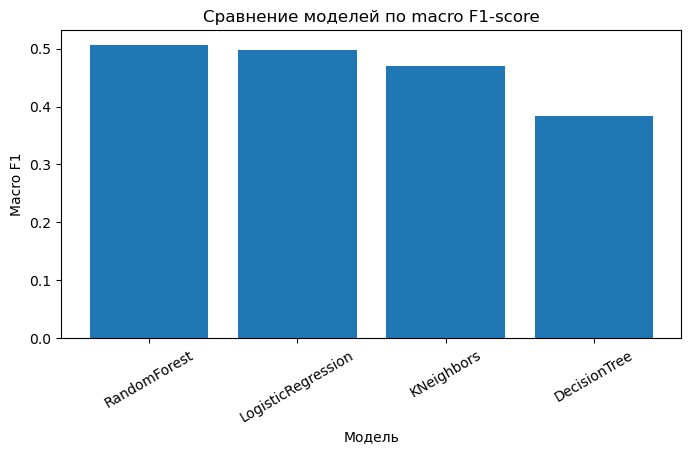

In [27]:
plt.figure(figsize=(8, 4))
plt.bar(results_df["model"], results_df["macro_f1"])
plt.title("Сравнение моделей по macro F1-score")
plt.xlabel("Модель")
plt.ylabel("Macro F1")
plt.xticks(rotation=30)
plt.show()

In [28]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Лучшая модель:", best_model_name)

Лучшая модель: RandomForest


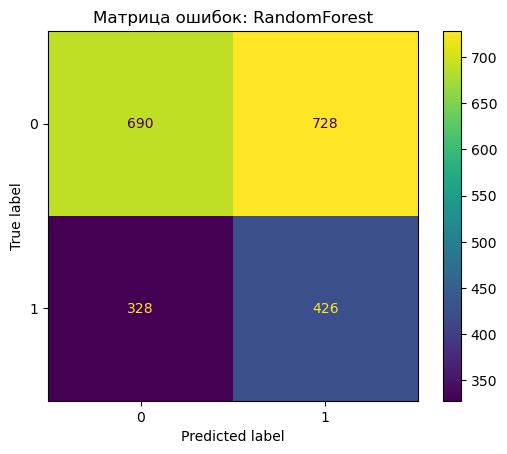

In [29]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

best_model.fit(X_train, y_train)
valid_pred = best_model.predict(X_valid)

cm = confusion_matrix(y_valid, valid_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Матрица ошибок: {best_model_name}")
plt.show()

## Выбор финальной модели

In [30]:
final_model = FinalModel(
    best_model,
    model_path="../models/final_model.joblib"
)

final_model.fit(X, y)
final_model.save()

Модель сохранена: ../models/final_model.joblib


## Предсказание на тестовой выборке

In [31]:
test_predictions = final_model.predict(X_test)

submission_maker = SubmissionMaker()
submission = submission_maker.make_submission(test_ids, test_predictions)

display(submission.head())

,id,prediction
0,7746,1
1,4202,1
2,6632,0
3,4639,0
4,4825,1


In [32]:
submission_path = submission_maker.save_submission(
    submission,
    path="../data/predictions/submission.csv"
)

Файл предсказаний сохранён: ../data/predictions/submission.csv
Размер файла: (966, 2)


In [33]:
check_df = pd.read_csv(submission_path, index_col=0)

print(check_df.head())
print(check_df.columns.tolist())
print(check_df.shape)

assert list(check_df.columns) == ["id", "prediction"]
assert len(check_df) == len(test)

print("Формат submission корректный")

     id  prediction
0  7746           1
1  4202           1
2  6632           0
3  4639           0
4  4825           1
['id', 'prediction']
(966, 2)
Формат submission корректный


## 📌 Общий вывод

В рамках проекта была решена задача бинарной классификации: предсказание риска сердечного приступа на основе медицинских, антропометрических и поведенческих признаков пациента.

На этапе первичного анализа были проверены размеры обучающей и тестовой выборок, типы данных, пропуски и дубликаты. Полные дубликаты и дубликаты по `id` не обнаружены. В ряде бинарных и дискретных признаков были выявлены пропуски, которые обрабатывались внутри пайплайна с помощью `SimpleImputer`.

Названия колонок были приведены к единому формату `snake_case`. Технический признак `id` был исключён из обучения и использовался только для формирования итогового файла предсказаний. Целевой признак `heart_attack_risk_binary` был выделен отдельно.

Была выполнена проверка признаков на возможные утечки целевого признака и сильную мультиколлинеарность. Явных признаков-утечек после проверки названий и корреляций не выявлено.

В качестве основной метрики выбрана `macro F1-score`, так как проверочный скрипт использует `classification_report`, а данные имеют умеренный дисбаланс классов. Дополнительно анализировались precision, recall и F1-score по классу высокого риска.

Для моделирования были протестированы несколько алгоритмов: LogisticRegression, RandomForestClassifier, GradientBoostingClassifier и CatBoostClassifier. Все модели были обучены через единый `Pipeline`, включающий обработку пропусков, масштабирование числовых признаков и кодирование категориального признака `gender`.

Финальная модель была обучена на всей обучающей выборке и сохранена в файл `models/final_model.joblib`. Для тестовой выборки сформирован файл `submission.csv` с двумя обязательными колонками: `id` и `prediction`.